# Архитектура Transformer. Обучение генеративного трансформера (GPT)

**Table of contents**<a id='toc0_'></a>    
- 1. [Раздел 1. Загрузка данных](#toc1_)    
- 2. [Раздел 2. Предварительная обработка и токенизация](#toc2_)    
  - 2.1. [Очистка сырого текста](#toc2_1_)    
  - 2.2. [Токенизация](#toc2_2_)    
  - 2.3. [Формирование X и y для next-token prediction](#toc2_3_)    
- 3. [Раздел 3. Паддинг последовательностей](#toc3_)    
- 4. [Раздел 4. Векторизация и DataLoader](#toc4_)    
- 5. [Раздел 5. Архитектура decoder-only Transformer](#toc5_)    
  - 5.1. [Векторизация входа и позиционное кодирование](#toc5_1_)    
  - 5.2. [Masked Multi-Head Self-Attention](#toc5_2_)    
  - 5.3. [Decoder Block](#toc5_3_)    
  - 5.4. [Полная архитектура decoder-only Transformer](#toc5_4_)    
- 6. [Раздел 6. Обучение модели](#toc6_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->


In [5]:
# Базовые библиотеки: математика, тензоры, модули сети
import numpy as np
import torch
import torch.nn as nn
import copy
import re

# Hugging Face tokenizers: обучаем word-level токенизатор на нашем корпусе
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.trainers import WordLevelTrainer
from tokenizers.normalizers import Sequence, NFKC, Lowercase
from tokenizers.pre_tokenizers import Sequence as PreTokenSequence
from tokenizers.pre_tokenizers import Whitespace, Punctuation, Digits

# Утилиты PyTorch для выравнивания длин последовательностей
from torch.nn.utils.rnn import pad_sequence

# Датасеты и загрузчики батчей
from torch.utils.data import DataLoader, TensorDataset


## 1. <a id='toc1_'></a>[Раздел 1. Загрузка данных](#toc0_)

В качестве источника данных использован датасет **TinyStories** с платформы Hugging Face:

- обучающая выборка (`train`): [TinyStories-train.txt](https://huggingface.co/datasets/roneneldan/TinyStories/blob/main/TinyStories-train.txt)  
- валидационная выборка (`valid`): [TinyStories-valid.txt](https://huggingface.co/datasets/roneneldan/TinyStories/blob/main/TinyStories-valid.txt)

На первом этапе выполним разбиение исходного корпуса по специальному разделителю `<|endoftext|>`, который отделяет одну историю от другой.

In [6]:
with open("data/TinyStories-train.txt", "r", encoding="utf-8") as file:
    text = file.read()

train_corpus = text.split('<|endoftext|>')

Чтобы сильно не перегружать оперативную память, сокращаем обучающую выборку на 50%: из **2 119 719** историй оставляем **1 059 859**. Для этого перемешиваем корпус (с фиксированным `seed`) и берём первые 50%.

In [7]:
original_train_size = len(train_corpus)
sample_size = original_train_size // 2

rng = np.random.default_rng(42)
rng.shuffle(train_corpus)
train_corpus = train_corpus[:sample_size]

print(f"Train size: {original_train_size} -> {len(train_corpus)}")

Train size: 2119719 -> 1059859


In [8]:
train_corpus[:5]

['\n\nTim and Mia like to play in the park. They see a big club on the ground. It is brown and long and heavy.\n"Look, a club!" Tim says. "I can lift it!"\nHe tries to lift the club, but it is too tough. He falls down and drops the club.\n"Ouch!" he says. "That hurt!"\nMia laughs. She is not mean, she just thinks it is funny.\n"Let me try!" she says. "I can balance it!"\nShe picks up the club and puts it on her head. She walks slowly and carefully. She does not fall down.\n"Wow!" Tim says. "You are good at balancing!"\n"Thank you!" Mia says. "It is fun!"\nThey take turns balancing the club on their heads, arms, and legs. They have a lot of fun with the club. They are happy and proud. They are good friends.\n',
 '\nOne day, a boy named Tim went to the store with his mom. They wanted to buy a toy. Tim found a big, expensive toy car. He asked his mom, "Can I have this car, please?" His mom said, "That car is too expensive. Let\'s trade it for a smaller car."\nTim was sad, but he agreed to

Аналогично читаем валидационный корпус.

Отдельная валидация нужна, чтобы контролировать переобучение.

In [9]:
with open("data/TinyStories-valid.txt", "r") as file:
    text = file.read()

valid_corpus = text.split('<|endoftext|>')


In [10]:
valid_corpus[:5]

[' Spot. Spot saw the shiny car and said, "Wow, Kitty, your car is so bright and clean!" Kitty smiled and replied, "Thank you, Spot. I polish it every day."\nAfter playing with the car, Kitty and Spot felt thirsty. They found a small pond with clear water. They drank the water and felt very happy. They played together all day and became best friends.\n',
 '\nOnce upon a time, in a big forest, there lived a rhinoceros named Roxy. Roxy loved to climb. She climbed trees, rocks, and hills. One day, Roxy found an icy hill. She had never seen anything like it before. It was shiny and cold, and she wanted to climb it.\nRoxy tried to climb the icy hill, but it was very slippery. She tried again and again, but she kept falling down. Roxy was sad. She wanted to climb the icy hill so much. Then, she saw a little bird named Billy. Billy saw that Roxy was sad and asked, "Why are you sad, Roxy?"\nRoxy told Billy about the icy hill and how she couldn\'t climb it. Billy said, "I have an idea! Let\'s f

## 2. <a id='toc2_'></a>[Раздел 2. Предварительная обработка и токенизация](#toc0_)

Чтобы обучать decoder-only Transformer на наших данных, нужно очистить текст, преобразовать в токены, а затем преобразовать токены в эмбеддинги.

### 2.1. <a id='toc2_1_'></a>[Очистка сырого текста](#toc0_)

Для классификации и генерации текст чистят по-разному, потому что у моделей разные цели.

В классификации модель должна понять общий смысл текста и отнести его к какому-то классу: например, отзыв положительный или отрицательный, письмо спам или не спам, сообщение токсичное или нормальное. Поэтому там можно сильнее упрощать текст: убирать лишние символы, иногда пунктуацию, приводить слова к нижнему регистру, удалять стоп-слова. Главное — сохранить смысл.

А в генерации модель должна не просто понять смысл, а научиться писать текст. То есть она должна уметь ставить запятые, точки, вопросительные знаки, сохранять порядок слов, структуру предложений и стиль. Поэтому для decoder-only модели нельзя слишком сильно чистить текст. Если убрать пунктуацию, модель потом и сама будет генерировать текст без нормальных точек и запятых.

Не будем учить модель абзацам, поэтому, заменим `\n`, `\t`, красивые кавычки на пробельный символ.

In [11]:
def clean_text(text: str) -> str:
    """
    Мягкая очистка текста для генерации:
    сохраняем пунктуацию и порядок слов, но убираем шумные служебные символы.
    """
    text = text.replace("\n", " ")
    text = text.replace("\t", " ")

    text = text.replace("“", '"').replace("”", '"')
    text = text.replace("‘", "'").replace("’", "'")

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [12]:
train_corpus = [clean_text(doc) for doc in train_corpus]
valid_corpus = [clean_text(doc) for doc in valid_corpus]

In [13]:
train_corpus[:5]

['Tim and Mia like to play in the park. They see a big club on the ground. It is brown and long and heavy. "Look, a club!" Tim says. "I can lift it!" He tries to lift the club, but it is too tough. He falls down and drops the club. "Ouch!" he says. "That hurt!" Mia laughs. She is not mean, she just thinks it is funny. "Let me try!" she says. "I can balance it!" She picks up the club and puts it on her head. She walks slowly and carefully. She does not fall down. "Wow!" Tim says. "You are good at balancing!" "Thank you!" Mia says. "It is fun!" They take turns balancing the club on their heads, arms, and legs. They have a lot of fun with the club. They are happy and proud. They are good friends.',
 'One day, a boy named Tim went to the store with his mom. They wanted to buy a toy. Tim found a big, expensive toy car. He asked his mom, "Can I have this car, please?" His mom said, "That car is too expensive. Let\'s trade it for a smaller car." Tim was sad, but he agreed to trade the expensi

### 2.2. <a id='toc2_2_'></a>[Токенизация](#toc0_)

Токенизацию будем выполнять на уровне слов с помощью библиотеки `tokenizers` от Hugging Face. В процессе обучения токенизатора на обучающем корпусе сразу будет построен словарь токенов `token -> id`.

Обязательно сделаем специальные токены: `<bos> - Beginning Of Sequence`, `<eos> — End Of Sequence`, `<pad> — Padding`, `<unk> — Unknown`

Используем такой конвейер токенизации:

1) Normalization — `NFKC`, `Lowercase`

    NFKC — нормализует Unicode-символы.

    Lowercase — переводит текст в нижний регистр.

2) Pre-tokenization — `Whitespace`, `Punctuation`, `Digits`

    Whitespace — разбивает текст по пробелам и границам слов.

    Punctuation — отделяет знаки препинания от слов.

    Digits — отделяет числа от букв.

3) Model — `WordLevel`

    WordLevel — сопоставляет каждый токен с числовым индексом из словаря. Если токена нет в словаре, он заменяется на `<unk>`.

Возьмем размер словаря 20 000 самых частых токенов. Все остальные редкие токены, которые не попадут в словарь, будут заменяться специальным токеном `<unk>`.

In [14]:
tokenizer = Tokenizer(model=WordLevel(unk_token="<unk>"))

# Нормализация
tokenizer.normalizer = Sequence([
    NFKC(), Lowercase()
    ])

# Предтокенизация
tokenizer.pre_tokenizer = PreTokenSequence([
    Whitespace(), 
    Punctuation(), 
    Digits()
    ])

# Ограничиваем словарь по частоте, чтобы контролировать размер модели и память
trainer = WordLevelTrainer(
    vocab_size=20000,
    special_tokens=["<pad>", "<unk>", "<bos>", "<eos>"]
)

tokenizer.train_from_iterator(train_corpus, trainer=trainer)

Проверим работу токенизатора.

In [15]:
print(tokenizer.get_vocab_size())
print(tokenizer.encode('One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp.').tokens)
print(tokenizer.encode('One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp.').ids)

20000
['one', 'day', ',', 'a', 'little', 'girl', 'named', 'lily', 'found', 'a', 'needle', 'in', 'her', 'room', '.', 'she', 'knew', 'it', 'was', 'difficult', 'to', 'play', 'with', 'it', 'because', 'it', 'was', 'sharp', '.']
[35, 28, 7, 9, 39, 53, 77, 24, 112, 9, 1755, 21, 16, 189, 4, 13, 159, 14, 11, 1303, 8, 49, 23, 14, 192, 14, 11, 861, 4]


Выведем весь наш словарь на 20000 токенов.

In [16]:
vocab = tokenizer.get_vocab()
vocab

{'bounciest': 19454,
 'nerve': 16072,
 'howie': 14258,
 'storage': 10206,
 'blood': 2515,
 'filed': 13699,
 'rosemary': 7990,
 'buggie': 19465,
 'opened': 265,
 'yawns': 6290,
 'farley': 11713,
 'spilled': 1683,
 'hehe': 18736,
 'advancing': 19357,
 'fetched': 5364,
 'recharged': 14068,
 'thunderclap': 10273,
 'curiouser': 18531,
 'gates': 5272,
 'successfully': 5097,
 'ambled': 13876,
 'skinny': 6095,
 'maggie': 2082,
 'rinse': 5601,
 'clumsly': 18501,
 'chipmunk': 4728,
 'coupon': 11191,
 'mismatched': 14906,
 'donald': 9826,
 'racey': 13561,
 'unload': 6185,
 'daddie': 18537,
 'warmly': 4550,
 'messiest': 11995,
 'magnetic': 15617,
 'shiny': 263,
 'goliath': 14518,
 'leaning': 3964,
 'tube': 2096,
 'light': 580,
 'skyward': 16702,
 'gigi': 3606,
 'silk': 6900,
 'eject': 15542,
 'blasting': 11584,
 'clinked': 9227,
 'opinion': 3545,
 'metal': 1566,
 'jackson': 6788,
 'anchorman': 18354,
 'willingly': 12964,
 'esta': 18601,
 'aaah': 12314,
 'snarled': 6271,
 'sloshing': 17383,
 'symph

Каждый документ в обучающем и валидационном корпусе преобразуем в последовательность индексов токенов. Для этого сначала применяем обученный токенизатор, затем добавляем специальные токены <bos> и <eos>. После этого все последовательности приводим к одной длине с помощью padding.

Получаем id спецтокенов один раз, чтобы дальше не хардкодить числа

In [17]:
bos_id = tokenizer.token_to_id('<bos>')
eos_id = tokenizer.token_to_id('<eos>')
pad_id = tokenizer.token_to_id('<pad>')
print(pad_id, bos_id, eos_id)

0 2 3


Добавляем границы последовательности: модель явно видит начало и конец истории.

In [18]:
train_tokens = [[bos_id] + tokenizer.encode(doc).ids + [eos_id] for doc in train_corpus]
valid_tokens = [[bos_id] + tokenizer.encode(doc).ids + [eos_id] for doc in valid_corpus]

### 2.3. <a id='toc2_3_'></a>[Формирование X и y для next-token prediction](#toc0_)

Задача состоит в генерации продолжения истории по её началу. Поэтому первая часть последовательности используется как исходный контекст для модели, а ошибка на этих токенах не считается. Loss рассчитывается только на второй части последовательности — на токенах продолжения, которые модель должна предсказать.

**Постановка обучения: генерация продолжения по начальному фрагменту текста**

Посчитаем длину каждой последовательности в токенах, чтобы определить реальную длину документов и правильно разделить их на исходный контекст и продолжение. Это также нужно для корректной работы с padding, так как `<pad>`-токены не должны учитываться при делении последовательности и расчёте ошибки.

`X` будет содержать всю последовательность токенов, кроме последнего токена. Первая часть последовательности будет использоваться как исходный контекст для модели.

`y` будет содержать ту же последовательность, но сдвинутую на один токен вправо. При этом ошибка будет считаться только на второй половине последовательности, то есть на продолжении истории. Для токенов из первой половины в `y` будет использоваться маска `<pad>`, чтобы они не участвовали в расчёте loss.

In [19]:
X_train = [tokens[:-1] for tokens in train_tokens]
y_train = [tokens[1:] for tokens in train_tokens]

In [20]:
X_valid = [tokens[:-1] for tokens in valid_tokens]
y_valid = [tokens[1:] for tokens in valid_tokens]

Длины без последнего токена: используем для маскирования prompt-части

In [21]:
story_length_train = [len(doc) - 1 for doc in X_train]
story_length_valid = [len(doc) - 1 for doc in X_valid]

In [22]:
def create_masked_labels(labels, real_lengths):
    """
    Маскируем первую половину y как <pad>, чтобы loss считался
    только на части "продолжение истории".
    """
    for i, tokens in enumerate(labels):
        prompt_len = real_lengths[i] // 2
        tokens[:prompt_len] = [pad_id] * prompt_len

    return labels

In [23]:
y_train = create_masked_labels(y_train, story_length_train)
y_valid = create_masked_labels(y_valid, story_length_valid)

## 3. <a id='toc3_'></a>[Раздел 3. Паддинг последовательностей](#toc0_)

Последовательности в корпусе имеют разную длину, а `DataLoader` формирует батчи только из тензоров одинаковой формы. Поэтому перед обучением мы выполним **padding**: короткие последовательности дополняются специальным токеном `<pad>` до длины самой длинной последовательности в батче.

Важно: `<pad>`-токены не несут смысловой нагрузки, поэтому они не должны влиять на обучение модели. Для этого при вычислении функции потерь используется `ignore_index=pad_id`, чтобы ошибка по позициям паддинга не учитывалась.

Дополнительно, из-за большого объёма данных (более 2 млн историй) удаляем промежуточные объекты из RAM, чтобы снизить риск `OOM (Out of Memory)`.

In [24]:
tensor_train_X = [torch.tensor(doc, dtype=torch.long) for doc in X_train]
padded_train_X = pad_sequence(sequences=tensor_train_X, batch_first=True, padding_value=vocab["<pad>"])

del tensor_train_X

In [25]:
tensor_train_y = [torch.tensor(doc, dtype=torch.long) for doc in y_train]
padded_train_y = pad_sequence(sequences=tensor_train_y, batch_first=True, padding_value=vocab["<pad>"])

del tensor_train_y

In [26]:
tensor_valid_X = [torch.tensor(doc, dtype=torch.long) for doc in X_valid]
padded_valid_X = pad_sequence(sequences=tensor_valid_X, batch_first=True, padding_value=vocab["<pad>"])

del tensor_valid_X

In [27]:
tensor_valid_y = [torch.tensor(doc, dtype=torch.long) for doc in y_valid]
padded_valid_y = pad_sequence(sequences=tensor_valid_y, batch_first=True, padding_value=vocab["<pad>"])

del tensor_valid_y

## 4. <a id='toc4_'></a>[Раздел 4. Векторизация и DataLoader](#toc0_)

Сделаем обучаемые позиционные эмбеддинги через слой nn.Embedding. В отличие от синусоидального позиционного кодирования, такие позиционные векторы будут обучаться вместе с моделью.

embedding_dim=300 – компромисс между качеством и скоростью на учебной задаче.

padding_idx фиксирует вектор <pad> и исключает его обучение.

In [28]:
embedding_layer = nn.Embedding(num_embeddings=len(vocab), embedding_dim=300, padding_idx=vocab["<pad>"])

Создадим TensorDataset и DataLoader

In [29]:
train_dataset = TensorDataset(padded_train_X, padded_train_y)
valid_dataset  = TensorDataset(padded_valid_X, padded_valid_y)

В train включаем shuffle, чтобы батчи были более разнообразными.

В valid shuffle не нужен: порядок не влияет на оценку лосса.

In [30]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

## 5. <a id='toc5_'></a>[Раздел 5. Архитектура decoder-only Transformer](#toc0_)

### 5.1. <a id='toc5_1_'></a>[Векторизация входа и позиционное кодирование](#toc0_)

Сделаем отдельный класс PositionalEncoding, который будет добавлять позиционное кодирование к эмбеддингам токенов. Наследуем его от nn.Module, чтобы он был частью общей PyTorch-модели и корректно работал вместе с остальными слоями.

Позиционные векторы заранее вычисляются и сохраняются внутри модели как buffer с помощью `register_buffer`. Buffer – это тензор, который хранится в модели, переносится на нужное устройство вместе с model.to(device) и сохраняется в state_dict, но не является обучаемым параметром и не обновляется оптимизатором.

Позиционное кодирование представляет собой сложение эмбеддингов с некоторыми уникальными (позиционными) векторами, которые характеризуют позицию токена в тексте.

В оригинальной статье авторы предложили использовать для этого синусоидальные функции разных частот:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

Здесь:

* $pos$ — позиция слова в предложении (0, 1, 2,...)
* $i$ — индекс компоненты вектора эмбеддинга (от 0 до $d_{\text{model}}/2 - 1$)
* $d_{\text{model}}$ — размерность эмбеддинга (в нашем случае 512)

In [31]:
class PositionalEncoding(nn.Module):
    def __init__(self, seq_len, dim_embedding):
        super().__init__()

        positional_vector = np.fromfunction(
            lambda i, j: np.where(
                j % 2 == 0,
                np.sin(i / (10000 ** (j / dim_embedding))),
                np.cos(i / (10000 ** ((j - 1) / dim_embedding)))
            ),
            shape=(seq_len, dim_embedding),
            dtype=float
        )

        positional_vector = torch.tensor(
            positional_vector, 
            dtype=torch.float32
        )

        positional_vector = positional_vector.unsqueeze(0)
        # Было: [seq_len, dim_embedding]
        # Стало: [1, seq_len, dim_embedding]
        # Почему так: батч размерности [B, L, D] сможет сложиться с позициями через broadcast.

        self.register_buffer('positional_vector', positional_vector)

    def forward(self, x):
        # Добавляем информацию о позиции к каждому токену
        x = x + self.positional_vector
        
        return x


### 5.2. <a id='toc5_2_'></a>[Masked Multi-Head Self-Attention](#toc0_)

Первый подслой decoder-only Transformer — `masked multi-head self-attention`. 
В отличие от обычного self-attention, здесь используется маскирование будущих позиций. 
Так как модель работает авторегрессионно, при обработке позиции `t` она должна учитывать только предыдущие токены и текущую позицию, но не должна иметь доступ к будущим токенам.

Для этого перед применением softmax к матрице оценок внимания добавляется causal mask. 
Все значения, соответствующие будущим позициям, заменяются на `-∞`. 
После softmax эти элементы превращаются в нули, поэтому будущие токены не участвуют в вычислении внимания.

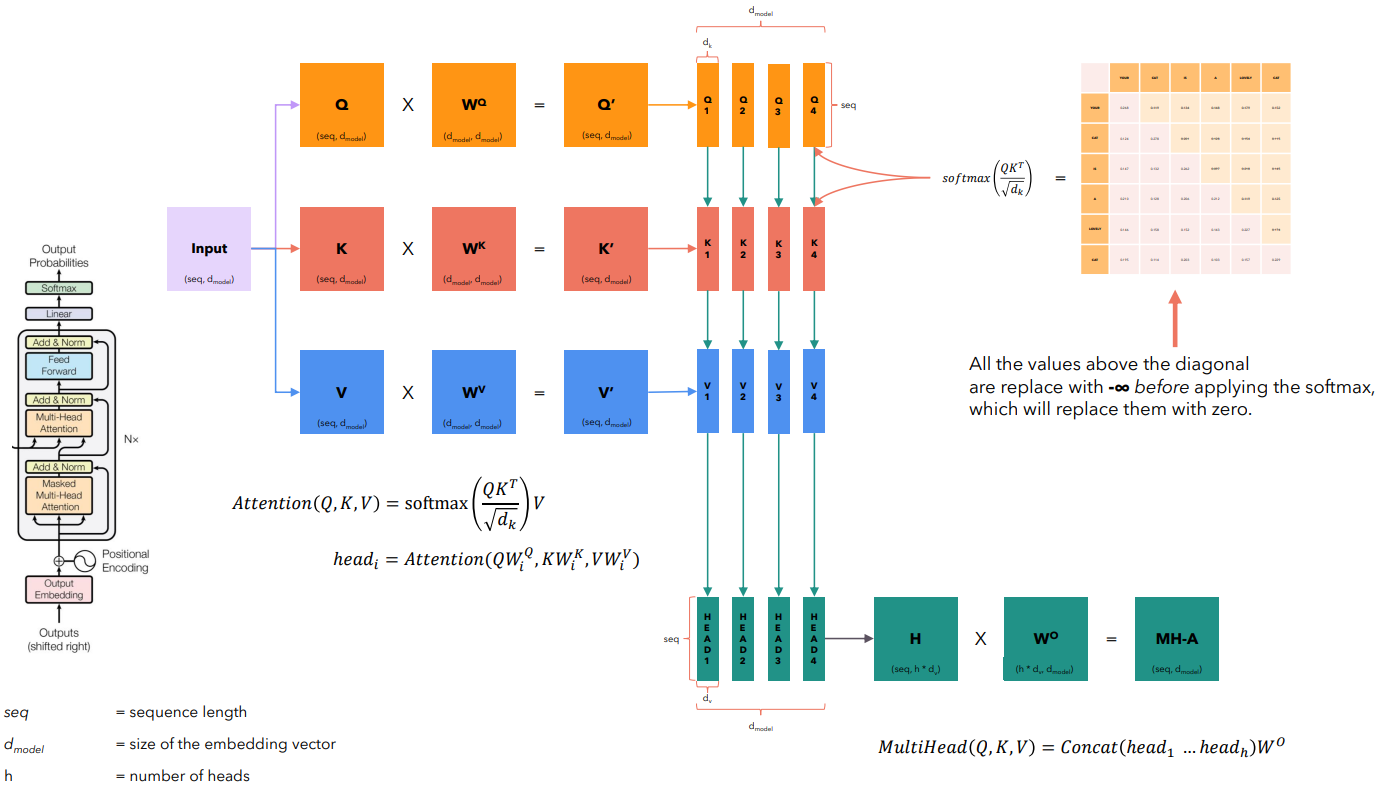

In [32]:
class MaskedMultiHeadSelfAttention(nn.Module):
    def __init__(self, dim_embedding, num_heads):
        super().__init__()

        assert dim_embedding % num_heads == 0, \
            "dim_embedding должен делиться на num_heads без остатка"

        self.num_heads = num_heads
        self.dim_embedding = dim_embedding
        self.head_dim = dim_embedding // num_heads

        self.q_proj = nn.Linear(dim_embedding, dim_embedding)
        self.k_proj = nn.Linear(dim_embedding, dim_embedding)
        self.v_proj = nn.Linear(dim_embedding, dim_embedding)

        self.w_proj = nn.Linear(dim_embedding, dim_embedding)

    def forward(self, x):
        Q = self.q_proj(x)
        K = self.k_proj(x)
        V = self.v_proj(x)
        
        # Разбиваем на головы:
        # было:  [batch_size, seq_len, dim_embedding]
        # стало: [batch_size, seq_len, num_heads, head_dim]
        Q = Q.view(Q.shape[0], Q.shape[1], self.num_heads, self.head_dim)
        K = K.view(K.shape[0], K.shape[1], self.num_heads, self.head_dim)
        V = V.view(V.shape[0], V.shape[1], self.num_heads, self.head_dim)

        # Меняем размерности местами, чтобы было удобно считать attention:
        # было:  [batch_size, seq_len, num_heads, head_dim]
        # стало: [batch_size, num_heads, seq_len, head_dim]
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)

        # Scaled dot-product attention
        attention_scores = Q @ K.transpose(-2, -1)
        attention_scores = attention_scores / np.sqrt(self.head_dim)

        # Causal mask запрещает видеть будущие токены (авторегрессия)
        mask = torch.triu(
            torch.ones(attention_scores.shape[2], attention_scores.shape[2], device=x.device), 
            diagonal=1
        ).bool()

        attention_scores = attention_scores.masked_fill(mask, float("-inf"))

        # После softmax замаскированные позиции становятся нулями
        attention_weights = torch.softmax(attention_scores, dim=-1)

        # Attention
        # attention_weights: [batch_size, num_heads, seq_len, seq_len]
        # V:                 [batch_size, num_heads, seq_len, head_dim]
        # attention:         [batch_size, num_heads, seq_len, head_dim]
        attention = attention_weights @ V

        # Возвращаем головы обратно:
        # было:  [batch_size, num_heads, seq_len, head_dim]
        # стало: [batch_size, seq_len, num_heads, head_dim]
        attention = attention.transpose(1, 2)

        # Склеиваем головы:
        # было:  [batch_size, seq_len, num_heads, head_dim]
        # стало: [batch_size, seq_len, dim_embedding]
        attention = attention.contiguous().view(
            attention.shape[0],
            attention.shape[1],
            self.dim_embedding
        )

        # Output
        output = self.w_proj(attention)

        return output

### 5.3. <a id='toc5_3_'></a>[Decoder Block](#toc0_)

Decoder Block объединяет masked self-attention и feed-forward слой с residual-связями и нормализацией.

In [33]:
class DecoderBlock(nn.Module):
    """
    Один блок декодера: Masked Self-Attention + FeedForward,
    оба с residual-связями и LayerNorm.
    """
    def __init__(self, dim_embedding, num_heads):
        super().__init__()

        self.attention = MaskedMultiHeadSelfAttention(dim_embedding, num_heads)
        self.norm_1 = nn.LayerNorm(dim_embedding)
        self.feed_forward = nn.Sequential(
            nn.Linear(dim_embedding, dim_embedding * 4),
            nn.GELU(),
            nn.Linear(dim_embedding * 4, dim_embedding)
        )
        self.norm_2 = nn.LayerNorm(dim_embedding)

    def forward(self, x):
        # 1) Attention: обновляем представления токенов с учетом контекста слева
        attention_output = self.attention(x) # [batch, seq_len, dim_embedding]

        # 2) Residual + Norm: стабилизируем обучение глубоких сетей
        x = self.norm_1(x + attention_output) # [batch, seq_len, dim_embedding]

        # 3) Position-wise FFN: нелинейная переработка признаков каждого токена
        ff = self.feed_forward(x) # [batch, seq_len, dim_embedding]

        # 4) Второй residual-блок
        x = self.norm_2(x + ff) # [batch, seq_len, dim_embedding]

        return x

### 5.4. <a id='toc5_4_'></a>[Полная архитектура decoder-only Transformer](#toc0_)

Ниже приведена архитектура модели типа decoder-only Transformer, которая используется для авторегрессионной генерации текста.

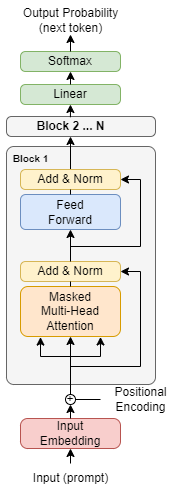

In [34]:
class DecoderOnlyTransformer(nn.Module):
    """
    Основной класс decoder-only Transformer для next-token prediction.
    """
    def __init__(
        self,
        embedding_layer,
        seq_len,
        dim_embedding,
        num_heads,
        num_layers,
        vocab_size
    ):
        super().__init__()

        self.embedding = embedding_layer
        self.positional_encoding = PositionalEncoding(seq_len, dim_embedding)

        self.decoder_blocks = nn.ModuleList([
            DecoderBlock(dim_embedding, num_heads)
            for _ in range(num_layers)
        ])

        self.classifier = nn.Sequential(
            nn.Linear(dim_embedding, dim_embedding * 3),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(dim_embedding * 3, dim_embedding),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(dim_embedding, vocab_size)
        )

    def forward(self, x):
        # Embedding
        x = self.embedding(x) # [batch, seq_len, dim_embedding]

        # Positional Encoding
        x = self.positional_encoding(x) # [batch, seq_len, dim_embedding]

        # Decoder Blocks
        for decoder_block in self.decoder_blocks:
            x = decoder_block(x) # [batch, seq_len, dim_embedding]

        # Classifier
        logits = self.classifier(x) # [batch, seq_len, vocab_size]

        return logits

## 6. <a id='toc6_'></a>[Раздел 6. Обучение модели](#toc0_)

In [35]:
def train_model_with_val(
    model,
    loss_fn,
    optimizer,
    train_loader,
    val_loader,
    epochs=20,
    patience=3,
    device="cpu"
):
    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    patience_counter = 0
    best_state = None

    model.to(device)

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0

        for x_b, y_b in train_loader:
            x_b = x_b.to(device)
            y_b = y_b.to(device)

            optimizer.zero_grad()

            logits = model(x_b)  # [batch, seq_len, vocab_size]

            # CrossEntropyLoss ждёт [batch, vocab_size, seq_len], поэтому делаем permute.
            logits = logits.permute(0, 2, 1)

            loss = loss_fn(logits, y_b)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for x_b, y_b in val_loader:
                x_b = x_b.to(device)
                y_b = y_b.to(device)

                logits = model(x_b)  # [batch, seq_len, vocab_size]
                logits = logits.permute(0, 2, 1)

                loss = loss_fn(logits, y_b)
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0

            # deepcopy обязателен, иначе best_state может перезаписаться дальше
            best_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1

        if (epoch + 1) % 2 == 0:
            print(
                f"Эпоха {epoch + 1:2d} | "
                f"Train Loss: {avg_train_loss:.4f} | "
                f"Val Loss: {avg_val_loss:.4f}"
            )

        if patience_counter >= patience:
            print(
                f"\nРанняя остановка на эпохе {epoch + 1}! "
                f"Val loss не улучшался {patience} эпох."
            )
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return train_losses, val_losses

Базовый конфиг для запуска.

In [36]:
seq_len = len(padded_train_X[0])
dim_embedding = 300
num_heads = 3
num_layers = 1
vocab_size = len(vocab)

model = DecoderOnlyTransformer(
    embedding_layer=embedding_layer,
    seq_len=seq_len,
    dim_embedding=dim_embedding,
    num_heads=num_heads,
    num_layers=num_layers,
    vocab_size=vocab_size
)

loss_fn = nn.CrossEntropyLoss(ignore_index=pad_id)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0025)

Перед запуском обучения проверим окружение PyTorch и доступность CUDA, чтобы зафиксировать, на каком устройстве будет идти обучение.

In [37]:
print(f"torch version: {torch.__version__}")
print(f"torch.version.cuda: {torch.version.cuda}")
print(f"cuda available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"cuda device count: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"  [{i}] {torch.cuda.get_device_name(i)}")
else:
    print("CUDA не обнаружена: обучение будет выполняться на CPU.")

torch version: 2.11.0
torch.version.cuda: None
cuda available: False
CUDA не обнаружена: обучение будет выполняться на CPU.


In [38]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"selected device: {device}")

train_losses, val_losses = train_model_with_val(
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=valid_loader,
    epochs=20,
    patience=3,
    device=device
)


selected device: cpu


KeyboardInterrupt: 